<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [18]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [19]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [7]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [8]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



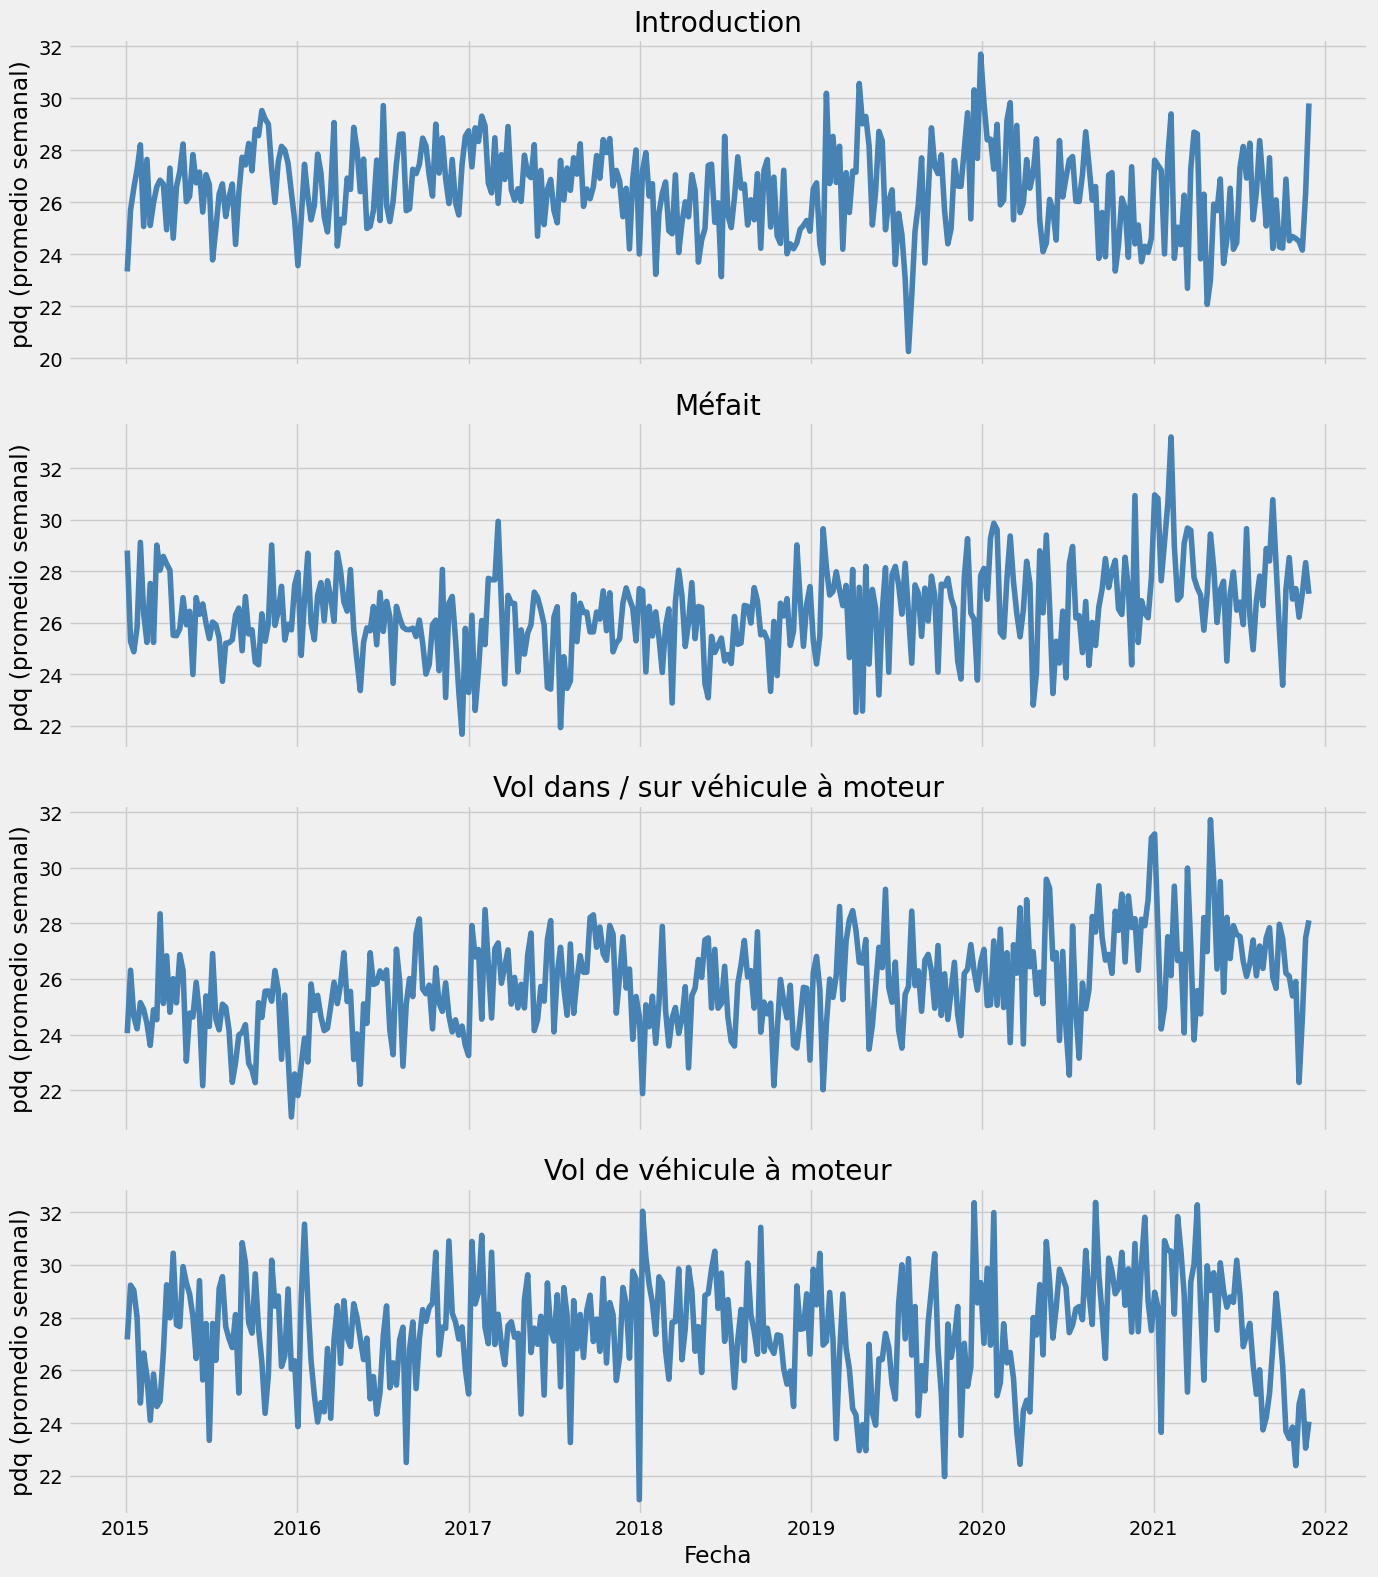

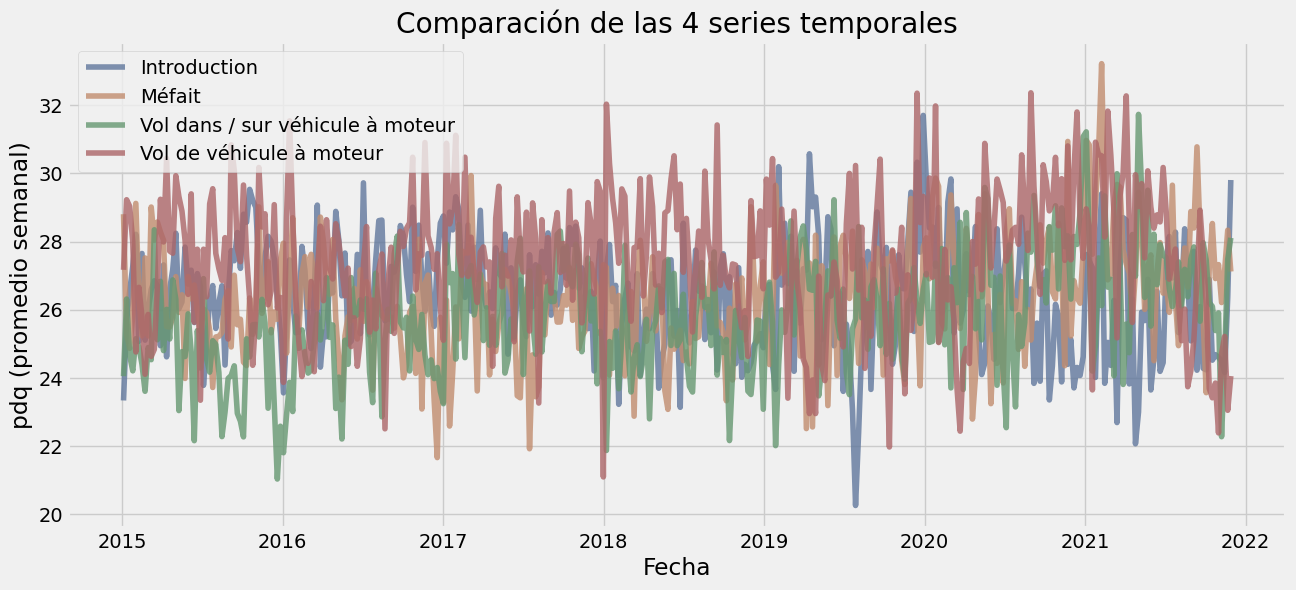

In [9]:
series = {'Introduction': y_s1, 'Méfait': y_s2, 'Vol dans / sur véhicule à moteur': y_s3, 'Vol de véhicule à moteur': y_s4}

fig, axs = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
for ax, (nombre, serie) in zip(axs, series.items()):
    ax.plot(serie.index, serie['pdq'], color='steelblue')
    ax.set_title(nombre)
    ax.set_ylabel('pdq (promedio semanal)')
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for nombre, serie in series.items():
    plt.plot(serie.index, serie['pdq'], label=nombre, alpha=0.8)
plt.legend()
plt.title('Comparación de las 4 series temporales')
plt.xlabel('Fecha')
plt.ylabel('pdq (promedio semanal)')
plt.show()

Las cuatro series muestran un comportamiento oscilante en torno a un nivel relativamente estable (entre 20 y 30 aprox.), con estacionalidad anual visible (picos y valles que se repiten cada 12 meses, coherentes con patrones estacionales de criminalidad ligados a clima/temporada) y sin una tendencia de crecimiento/decrecimiento marcada a largo plazo. Se observa además mayor variabilidad/ruido en algunas categorías (como "Vol de véhicule à moteur") que en otras.



1. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



In [11]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'

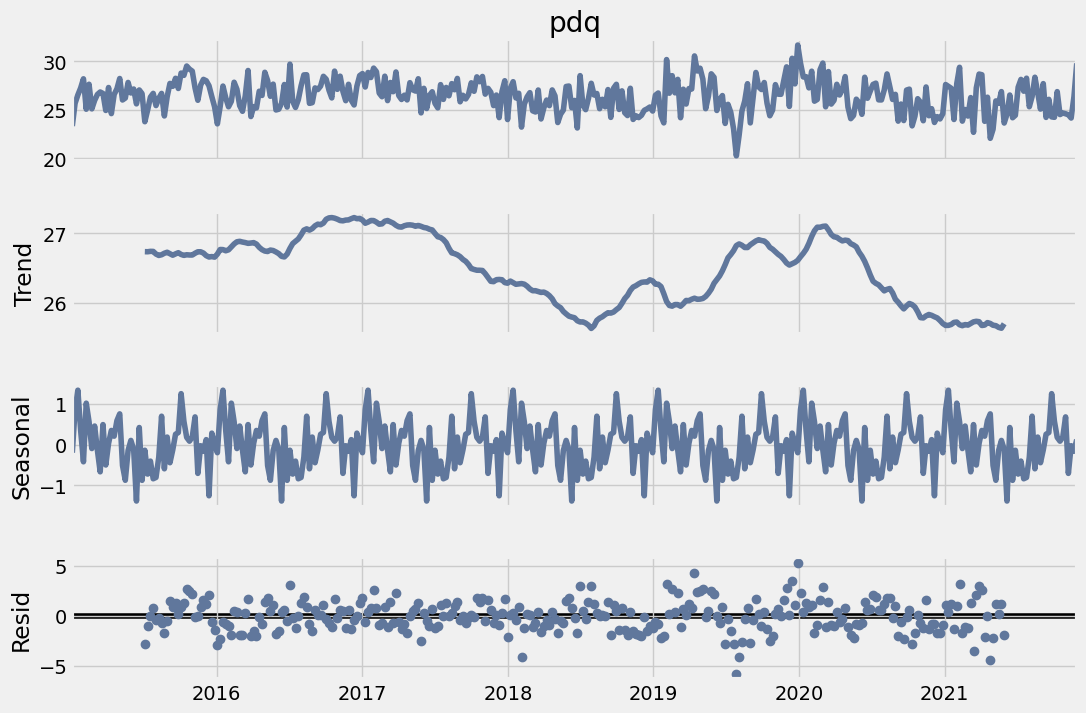

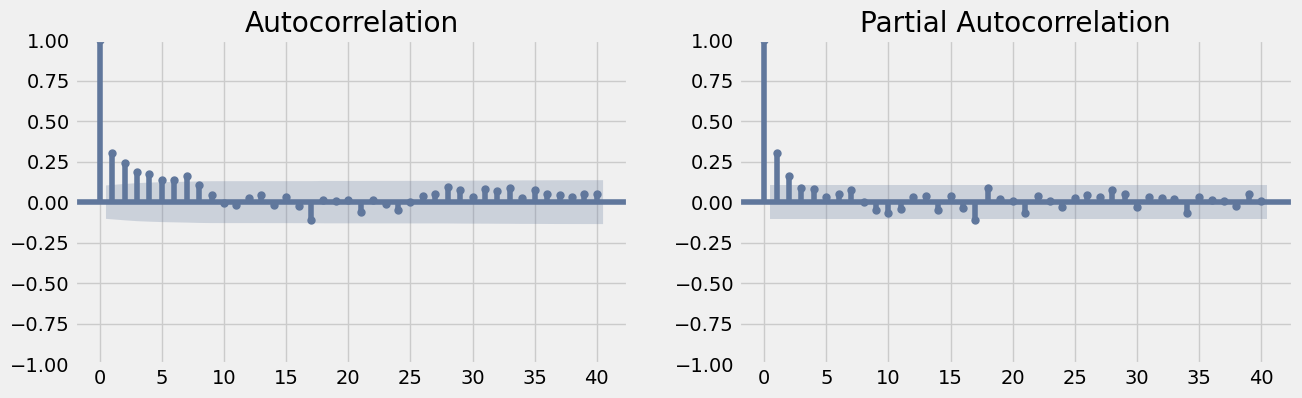

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


       mae     mse    rmse    mape   maape   wmape   mmape   smape  \
5   1.5876  3.4224  1.8500  0.0622  0.0620  0.0614  0.0599  0.0614   
13  1.5934  3.4304  1.8521  0.0624  0.0622  0.0616  0.0600  0.0616   
37  1.6021  3.4537  1.8584  0.0627  0.0625  0.0619  0.0603  0.0619   
7   1.6444  3.7833  1.9451  0.0654  0.0651  0.0635  0.0629  0.0635   
3   1.6444  3.7832  1.9451  0.0654  0.0651  0.0635  0.0629  0.0635   
11  1.6576  3.8281  1.9566  0.0659  0.0657  0.0641  0.0634  0.0640   
15  1.6576  3.8281  1.9566  0.0659  0.0657  0.0641  0.0634  0.0640   
35  1.6704  3.8611  1.9650  0.0664  0.0661  0.0646  0.0638  0.0645   
39  1.6704  3.8611  1.9650  0.0664  0.0661  0.0646  0.0638  0.0645   
43  1.6905  3.8859  1.9713  0.0667  0.0664  0.0653  0.0641  0.0653   

                        model  
5   SARIMA_(0,0,0)X(1,0,1,12)  
13  SARIMA_(0,0,1)X(1,0,1,12)  
37  SARIMA_(1,0,0)X(1,0,1,12)  
7   SARIMA_(0,0,0)X(1,1,1,12)  
3   SARIMA_(0,0,0)X(0,1,1,12)  
11  SARIMA_(0,0,1)X(0,1,1,12)  
15  S

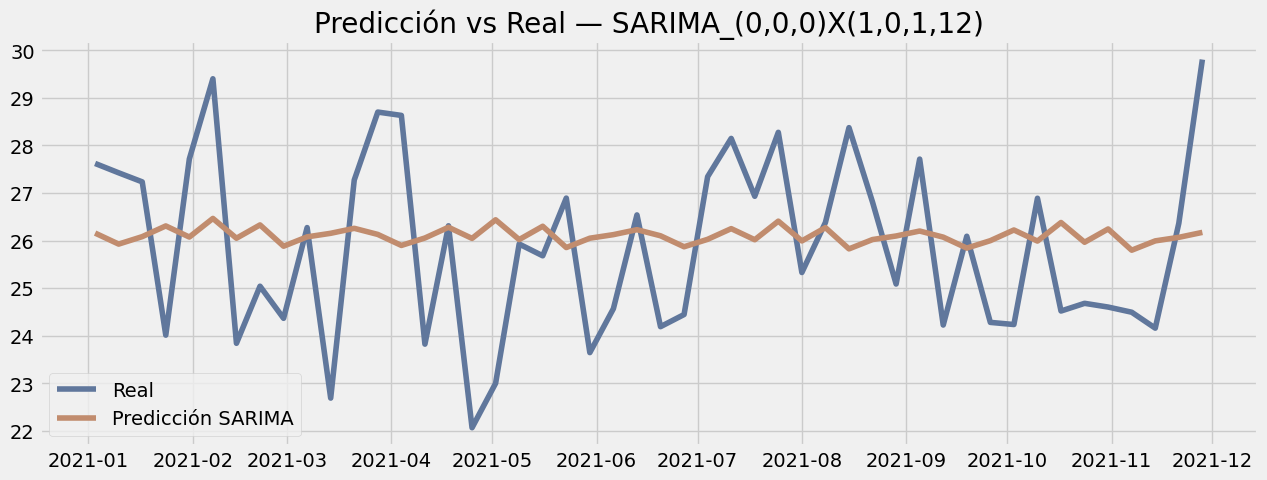

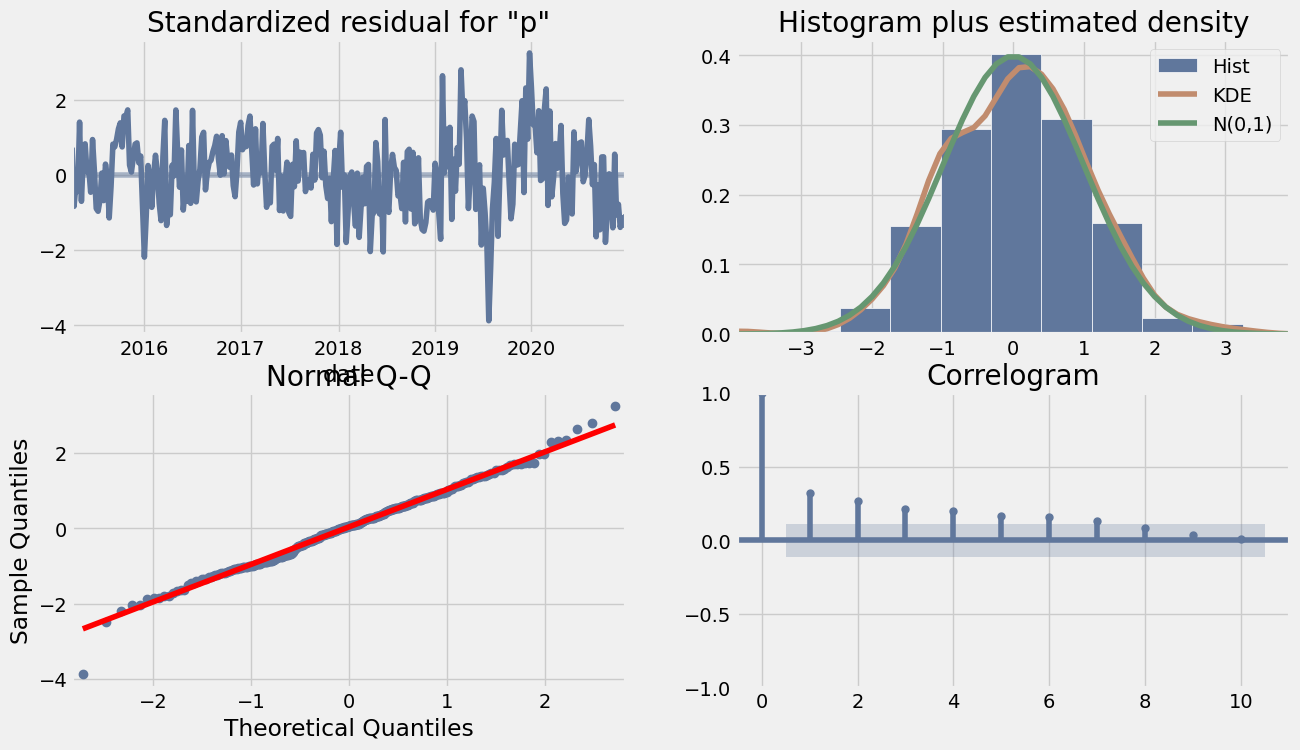

       lb_stat      lb_pvalue
10  980.960115  2.360699e-204


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

y = y_s1

decomposition = seasonal_decompose(y['pdq'], model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y['pdq'], lags=40, ax=axs[0])
plot_pacf(y['pdq'], lags=40, ax=axs[1])
plt.show()

resultados = []
for par in params:
    try:
        sm_model = SarimaModels(par)
        met = sm_model.metrics(y, target_date)
        resultados.append(met)
    except Exception:
        continue

tabla_resultados = pd.concat(resultados, ignore_index=True).sort_values('rmse')
print(tabla_resultados.head(10))

mejor_params = params[tabla_resultados.index[0]] if False else None

mejor_nombre = tabla_resultados.iloc[0]['model']
mejor_par = [p for p in params if f"SARIMA_{p[0]}X{p[1]}".replace(' ', '') == mejor_nombre][0]

mejor_modelo = SarimaModels(mejor_par)
model_fit = mejor_modelo.fit_model(y, target_date)
df_pred = mejor_modelo.df_testig(y, target_date)

plt.figure(figsize=(14, 5))
plt.plot(df_pred.index, df_pred['y'], label='Real')
plt.plot(df_pred.index, df_pred['yhat'], label='Predicción SARIMA')
plt.legend()
plt.title(f'Predicción vs Real — {mejor_nombre}')
plt.show()

model_fit.plot_diagnostics(figsize=(14, 8))
plt.show()

residuos = model_fit.resid
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(lb_test)

La serie y_s1 (Introduction) no muestra tendencia marcada pero sí una fuerte componente estacional anual (period=52 en la descomposición), consistente con lo observado en la Pregunta 1. Al probar las 64 combinaciones de (p,d,q)×(P,D,Q,12), el modelo con mejor desempeño en el conjunto de prueba (desde 2021-01-01) fue SARIMA(0,0,0)×(1,0,1,12), es decir, un modelo sin componente ARIMA no-estacional, dominado enteramente por el término estacional autorregresivo-móvil de periodo 12. Esto es razonable porque, tras agregar a nivel semanal, la señal dominante es la estacionalidad anual y no hay estructura autorregresiva de corto plazo relevante.
Sin embargo, el test de Ljung-Box sobre los residuos (lag=10) dio un p-value ≈ 0 (estadístico ≈ 981), lo que significa que se rechaza la hipótesis nula de ausencia de autocorrelación: los residuos no se comportan como ruido blanco. Esto indica que el modelo, aunque es el mejor entre los probados, todavía deja estructura sin explicar (probablemente estacionalidad residual de alta frecuencia o outliers no capturados). Sería necesario ampliar la grilla de búsqueda (permitir d>1, más rezagos estacionales, o un periodo estacional distinto a 12 dado que los datos son semanales) para mejorar el ajuste.




3. Resuelva el ejercicio anterior utilizando la librería **`Prophet`**, desarrollada por Facebook para el modelado de series temporales.

* **Ajuste del modelo**: entrene un modelo con `Prophet` sobre la misma serie seleccionada en el punto anterior.
* **Evaluación del desempeño**: compare la capacidad predictiva de `Prophet` frente al modelo **SARIMA** previamente ajustado, considerando métricas de error (por ejemplo, MAE, RMSE o MAPE).
* **Análisis comparativo**: discuta las diferencias en los supuestos de ambos métodos, su facilidad de implementación y la calidad de las predicciones obtenidas.
* **Conclusiones**: señale en qué situaciones `Prophet` puede ser preferible a SARIMA y viceversa.


In [16]:
from prophet import Prophet

Prophet -> MAE: 1.7079 RMSE: 2.0324 MAPE: 0.067


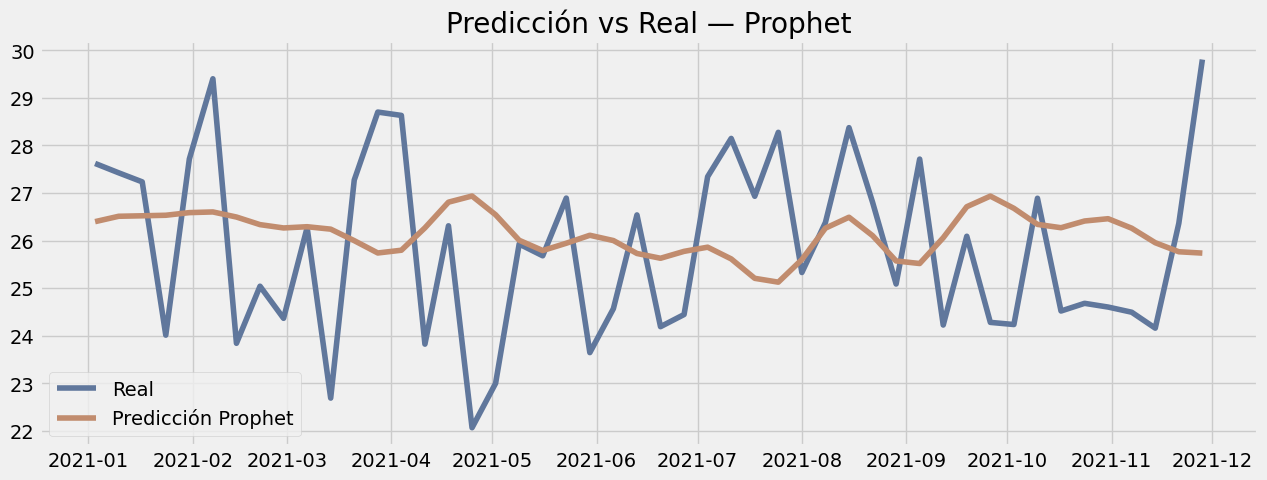

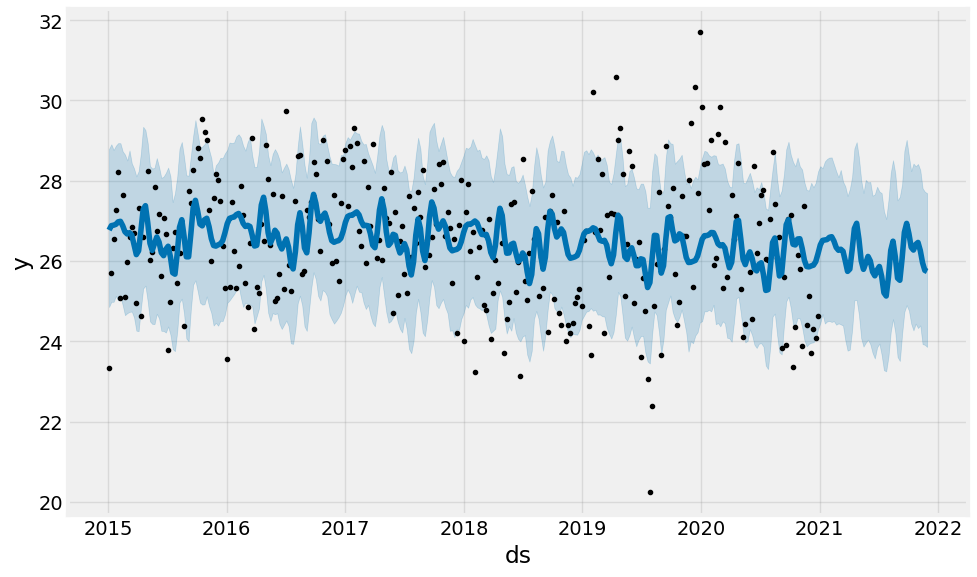

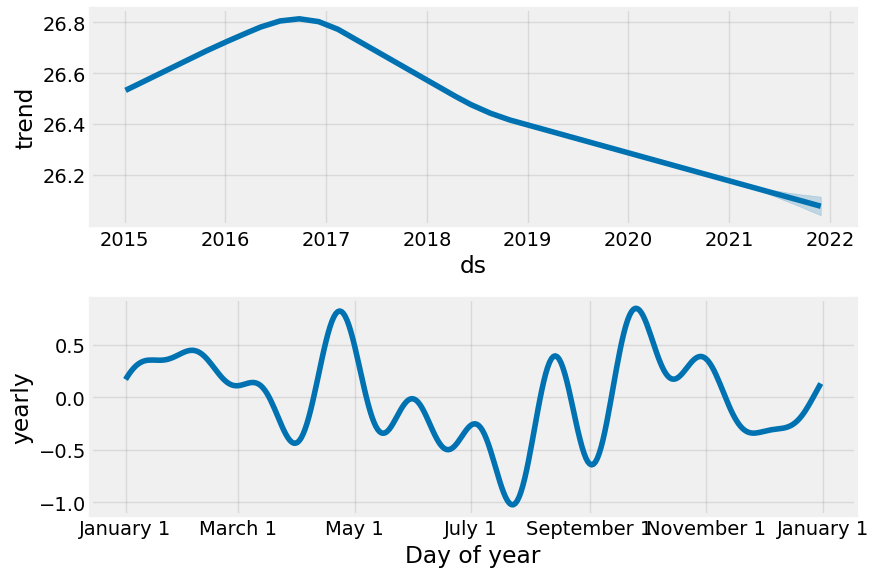

In [22]:
from prophet import Prophet

# Prophet requiere columnas 'ds' (fecha) y 'y' (valor)
y_prophet = y_s1.reset_index().rename(columns={'date': 'ds', 'pdq': 'y'})

target_date = '2021-01-01'
train = y_prophet[y_prophet['ds'] < target_date]
test = y_prophet[y_prophet['ds'] >= target_date]

model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_prophet.fit(train)

future = model_prophet.make_future_dataframe(periods=len(test), freq='W')
forecast = model_prophet.predict(future)

df_pred_prophet = forecast[['ds', 'yhat']].set_index('ds').join(y_prophet.set_index('ds'))
df_pred_prophet = df_pred_prophet.dropna()
df_test_prophet = df_pred_prophet.loc[df_pred_prophet.index >= target_date]

mae_p = mae(df_test_prophet['y'].values, df_test_prophet['yhat'].values)
rmse_p = rmse(df_test_prophet['y'].values, df_test_prophet['yhat'].values)
mape_p = mape(df_test_prophet['y'].values, df_test_prophet['yhat'].values)
print("Prophet -> MAE:", mae_p, "RMSE:", rmse_p, "MAPE:", mape_p)

plt.figure(figsize=(14, 5))
plt.plot(df_test_prophet.index, df_test_prophet['y'], label='Real')
plt.plot(df_test_prophet.index, df_test_prophet['yhat'], label='Predicción Prophet')
plt.legend()
plt.title('Predicción vs Real — Prophet')
plt.show()

fig1 = model_prophet.plot(forecast)
fig2 = model_prophet.plot_components(forecast)
plt.show()

Desempeño: en esta serie, SARIMA superó levemente a Prophet en las tres métricas (MAE, RMSE y MAPE), aunque la diferencia es pequeña (~10-12%). Ambos modelos capturan bien la estacionalidad anual, pero SARIMA se ajustó mejor a la escala/nivel de los datos de prueba.
Diferencias en supuestos: SARIMA asume una estructura lineal autorregresiva/de medias móviles sobre una serie (idealmente) estacionaria, y requiere que el usuario elija explícitamente el orden (p,d,q) y la estacionalidad (P,D,Q,S), lo que exige un proceso de búsqueda de hiperparámetros (como el grid search hecho arriba). Prophet, en cambio, modela la serie como una suma de componentes (tendencia + estacionalidad + efectos de días festivos) mediante un modelo aditivo tipo GAM, es más robusto a datos faltantes y outliers, y no requiere que la serie sea estacionaria.
Facilidad de implementación: Prophet es más simple de usar (solo requiere columnas ds/y y ajusta automáticamente estacionalidad y tendencia), mientras que SARIMA exige más trabajo manual (identificación de d, revisión de ACF/PACF, búsqueda de hiperparámetros) pero da más control e interpretabilidad estadística (tests de residuos, significancia de coeficientes).
Cuándo preferir cada uno: Prophet es preferible cuando se necesita un modelo rápido de implementar, con múltiples estacionalidades o feriados, y cuando los datos tienen missing values o cambios de tendencia (changepoints) frecuentes. SARIMA es preferible cuando se dispone de una serie relativamente limpia y estacionaria (o fácilmente diferenciable), se necesita rigor estadístico (inferencia sobre coeficientes, diagnóstico de residuos) y se busca exprimir el máximo desempeño ajustando finamente los hiperparámetros, como ocurrió en este caso donde SARIMA terminó con mejor error.